In [5]:
import elegy
import matplotlib.pyplot as plt
from lgsm.plotting import *
import pickle
import numpy as np

from lgsm.sed_utils import setup_wave_grid

In [3]:
model = elegy.load("../models/default_model")

In [4]:
with open("../data/raw/simulated_seds.pkl", "rb") as file:
    sims = pickle.load(file)
    sim_wave = sims["wave"]
    sim_mag = sims["sed_mag"]
    del sims

In [6]:
wave = setup_wave_grid(1e3, 11e3, 64)

In [10]:
with open("../data/processed/simulated_photometry.pkl", "rb") as file:
    sims = pickle.load(file)
    key = sims["data"][:, 0].astype(int)
    amps = np.array(sims["data"][:, 1])
    data = np.array(sims["data"][:, 2:])
    del sims

In [11]:
y_train = model.predict(x=data[:100])

NameError: name 'plot_sed' is not defined

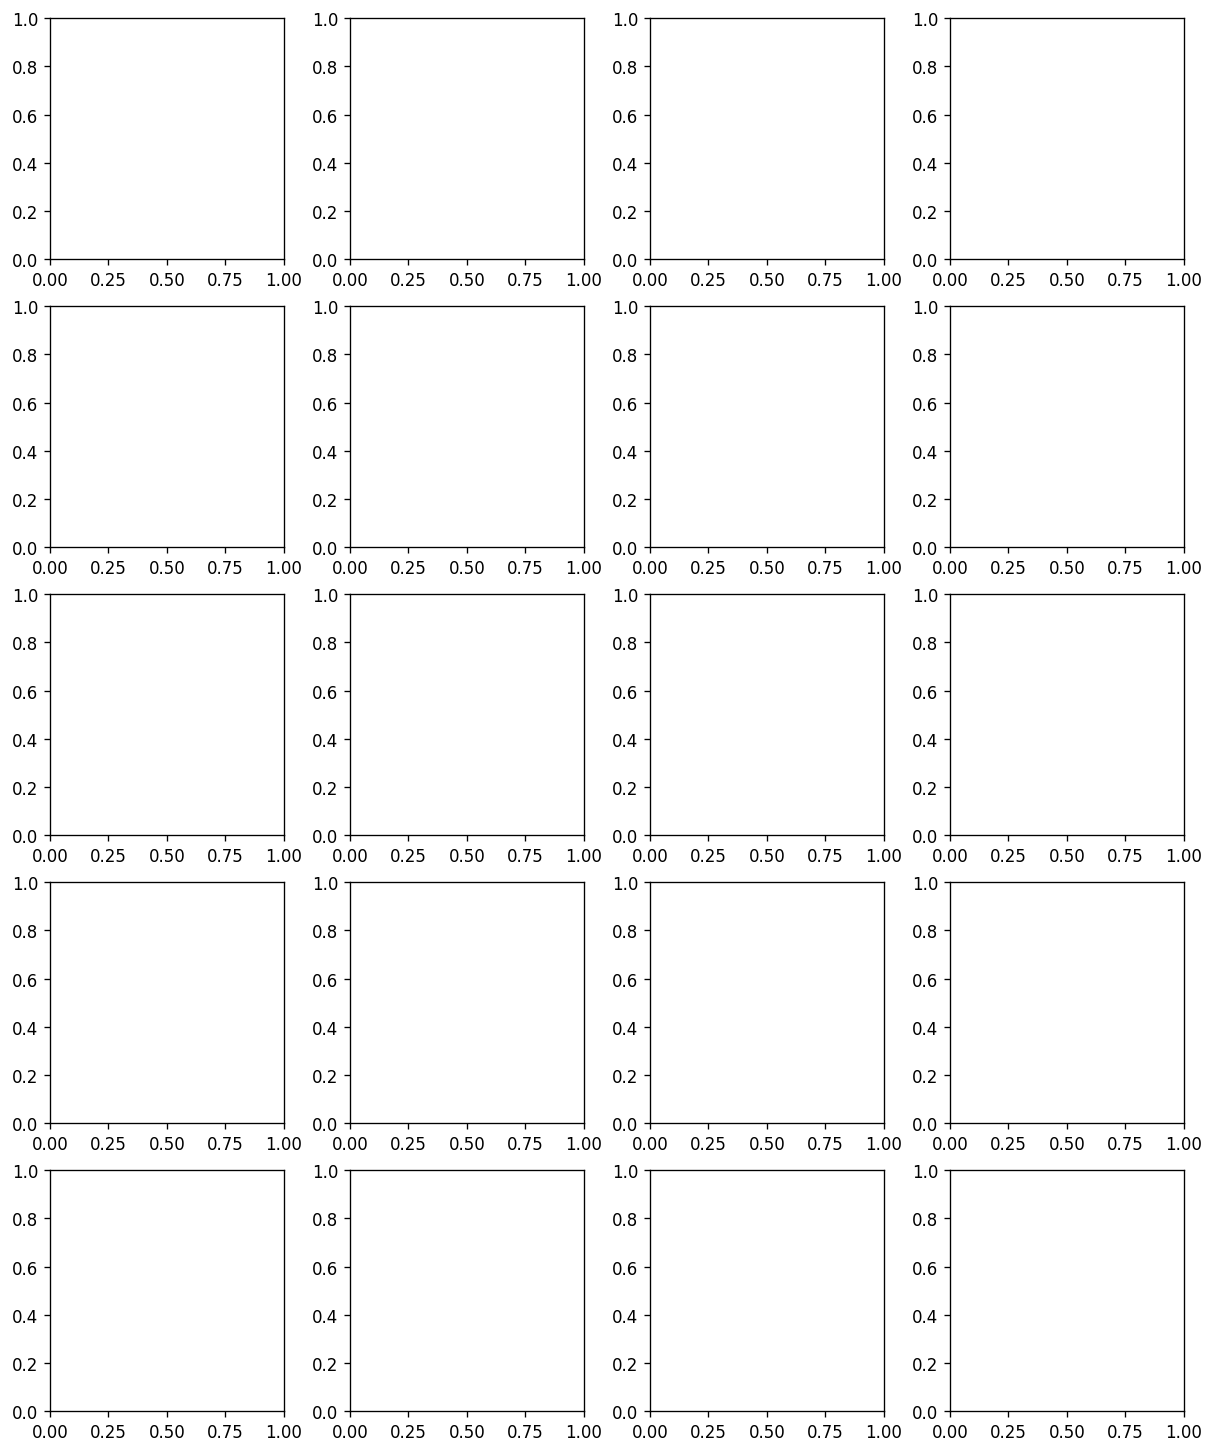

In [12]:
ncols = 4
nrows = 5
fig, axes = plt.subplots(nrows, ncols, figsize=(10, 12), dpi=120, constrained_layout=True)

for i, ax in enumerate(axes.flatten()):
    # true sed
    plot_sed(sim_wave, sim_mag[key[i]] + amps[i], ax=ax)
    # true photometry
    plot_photometry(data[i, 1:], settings.default_settings["bandpasses"], 
                    scatter_settings={"facecolors":"C0", "edgecolors":"k", "zorder":10}, ax=ax, z=data[i, 0])
    
    # predicted sed
    plot_sed(sed_wave, y_train["sed_mag"][i] + y_train["amplitude"][i], 
            ax=ax)
    # predicted photometry
    plot_photometry(y_train["predicted_photometry"][i], settings.default_settings["bandpasses"], 
                    scatter_settings={"facecolors":"C1", "edgecolors":"k", "zorder":10}, ax=ax, z=data[i, 0])
    
    ax.invert_yaxis()

    if i % ncols != 0:
        ax.set(ylabel="")
    if i < ncols * nrows:
        ax.set(xlabel="")

In [26]:
import jax.numpy as jnp

In [43]:
x = jnp.array([
    [1, 2, 3],
    [0, 1, 0],
    [0, 0, 0], 
    [3, 0, 0],
])

In [44]:
jnp.sum((x[:, None, ...] - x[None, ...])**2, axis=-1)

DeviceArray([[ 0, 11, 14, 17],
             [11,  0,  1, 10],
             [14,  1,  0,  9],
             [17, 10,  9,  0]], dtype=int32)

In [45]:
def sq_distance_matrix(x, y):
    """
    Returns the pairwise squared-distance matrix
    where A_ij = (x_i - y_j)**2.
    Works in any number of dimensions.
    """
    return jnp.sum((x[:, None, ...] - y[None, ...])**2, axis=-1)

In [50]:
def kernel(x, y):
    """
    Computes the Gaussian kernel 
    """
    # set the hyperparam to 2 / dim
    dim = x.shape[1]
    simga_sq = 2 / dim

    # compute the matrix of square distances
    sq_dist_matrix = jnp.sum((x[:, None, ...] - y[None, ...])**2, axis=-1)

    # compute and return the kernel
    return jnp.exp(-sq_dist_matrix.mean(axis=-1) / (2 * simga_sq))

In [59]:
def max_mean_discrepancy(x, y):
    """
    Computes the Maximum-Mean Discrepancy (MMD)
    """
    return kernel(x, x) + kernel(x, x) - 2 * kernel(x, y)

In [60]:
max_mean_discrepancy(x, x)

DeviceArray([0., 0., 0., 0.], dtype=float32)